In [1]:
import os
import json
import pandas as pd
from transformers import pipeline
import torch
from tqdm import tqdm

rows = []
erros = []

# Itera por cada profundidade
for depth in range(3 + 1):
    dir_ = f"../data/raw/expansao/{depth}/subreddits"
    if not os.path.exists(dir_):
        continue
    for filename in os.listdir(dir_):
        if filename.endswith(".json"):
            path = os.path.join(dir_, filename)
            try:
                with open(path, "r", encoding="utf-8") as f:
                    posts = json.load(f)
                # Adiciona a profundidade em cada post para rastreabilidade
                for post in posts:
                    post["depth"] = depth
                rows.extend(posts)
            except json.JSONDecodeError:
                erros.append(path)


df = pd.DataFrame(rows)
print(f"Quantidade de mensagens no df original: {len(df)}")

/home/mateus/reddit/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Quantidade de mensagens no df original: 2227113


In [2]:
df = df.drop(columns=['lang', 'text'], errors='ignore')
df.columns

Index(['id', 'title', 'selftext', 'author', 'subreddit', 'score', 'timestamp',
       'num_comments', 'url', 'is_self', 'over_18', 'removed_by_category',
       'depth'],
      dtype='str')

### **Removendo Duplicatas**

In [4]:
df = df.drop_duplicates(subset='id', keep='first')
print(f"Quantidade de mensagens no df: {len(df)}")

Quantidade de mensagens no df: 2135757


### **Filtrando idioma**

In [8]:
df_lang = pd.read_csv("../data/processed/lang_detection.csv")
df_lang

,id,lang,lang_roberta
0,1k7yqzv,tl,it
1,1iyt2ym,de,nl
2,1j4vidt,unknown,hi
3,1k70gml,it,en
4,1k9dzgp,it,ur
...,...,...,...
2227103,14ifnii,en,en
2227104,zqyg79,en,en
2227105,c6e90e,en,en
2227106,r8kbmz,en,en


In [9]:
df = df.merge(df_lang, how='left', on='id')

In [10]:
contagem_l = len(df[df['lang']=='en'])
contagem_r = len(df[df['lang_roberta']=='en'])
print(f"Número de posts classificados como de língua inglesa pelo langdetect: {contagem_l}")
print(f"Número de posts classificados como de língua inglesa pelo roberta: {contagem_r}")

Número de posts classificados como de língua inglesa pelo langdetect: 1832330
Número de posts classificados como de língua inglesa pelo roberta: 1946061


In [11]:
df = df[df['lang_roberta']=='en']

Escolhemos a classificação do roberta

### **Removendo nulos**

In [12]:
df_2 = pd.read_csv("../data/processed/preprocess_text.csv")
df_2 = df_2[df_2['id'].isin(df['id'])]
print(f"Quantidade de posts cruzados: {len(df_2)}")
display(df_2.head())

Quantidade de posts cruzados: 1946061


,id,text,text_clean
0,1j3g0q5,Trudeau - ''I want to speak first directly to ...,trudeau want speak first directly american peo...
1,1jdfbt3,Kim Kardashian endorses Nazi Elon Musk’s cyber...,kardashian endorses nazi elon musk cybertruck ...
2,1k7jcux,Candace Owens saying she no longer supports Do...,candace owen long support donald trump
3,1ilwij6,Kendrick Lamar called out for no white perform...,kendrick lamar call white performer super bowl...
4,1jfzx63,"Elon Musk's daughter, Vivian Wilson, stars in ...",elon musk daughter vivian wilson star first ev...


In [13]:
nulos = df_2['text_clean'].isna().sum()
print(f'Quantidade de nulos na coluna text_clean: {nulos}')

Quantidade de nulos na coluna text_clean: 36315


In [14]:
df_2 = df_2.dropna(subset=['text_clean'])

In [15]:
print(f'Df após remoção de nulos: {len(df_2)}')

Df após remoção de nulos: 1909746


### **Filtrando textos pequenos**

In [ ]:
one_word = df_2[df_2['text_clean'].str.split().str.len() == 1]
print(f"Quantidade de mensagens com 1 palavra: {len(one_word)}")

Quantidade de mensagens com 1 palavra: 173644


In [ ]:
one_word = df_2[df_2['text_clean'].str.split().str.len() == 1]
print(f"Quantidade de mensagens com 1 palavra: {len(one_word)}")

two_word = df_2[df_2['text_clean'].str.split().str.len() == 2]
print(f"Quantidade de mensagens com 2 palavras: {len(two_word)}")

three_word = df_2[df_2['text_clean'].str.split().str.len() == 3]
print(f"Quantidade de mensagens com 3 palavras: {len(three_word)}")

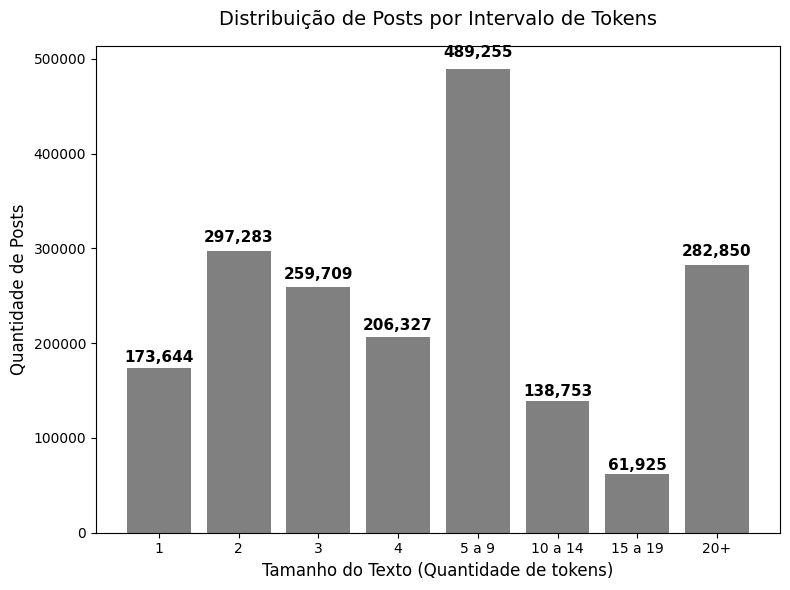

In [15]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Supondo que df_2 já exista
tamanhos = df_2['text_clean'].str.split().str.len()

# Começamos no 1 (excluindo o 0) e usamos np.inf para pegar de 20 ao infinito
bins = [1, 2, 3, 4, 5, 10, 15, 20, np.inf]

# 9 limites geram 8 categorias exatas
labels = ['1', '2', '3', '4', '5 a 9', '10 a 14', '15 a 19', '20+']

# O pd.cut com right=False faz intervalos do tipo [1, 2), [2, 3)... e [20, inf)
contagem_intervalos = pd.cut(tamanhos, bins=bins, labels=labels, right=False).value_counts().sort_index()

plt.figure(figsize=(8, 6))
barras = plt.bar(contagem_intervalos.index, contagem_intervalos.values, color='gray')

for barra in barras:
    altura = barra.get_height()
    if altura > 0:
        plt.text(barra.get_x() + barra.get_width()/2, altura + (altura * 0.02) + 5, 
                 f'{int(altura):,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Títulos e labels
plt.title('Distribuição de Posts por Intervalo de Tokens', fontsize=14, pad=15)
plt.xlabel('Tamanho do Texto (Quantidade de tokens)', fontsize=12)
plt.ylabel('Quantidade de Posts', fontsize=12)

plt.tight_layout()
plt.show()

In [12]:
textos_5 = df_2[df_2['text_clean'].str.len() <= 5]
print(f"Quantidade de mensagens pequenos no pre processado: {len(textos_5)}")

textos_10 = df_2[df_2['text_clean'].str.len() <= 10]
print(f"Quantidade de mensagens pequenos no pre processado: {len(textos_10)}")

textos_15 = df_2[df_2['text_clean'].str.len() <= 15]
print(f"Quantidade de mensagens pequenos no pre processado: {len(textos_15)}")

textos_15 = df_2[df_2['text_clean'].str.len() <= 20]
print(f"Quantidade de mensagens pequenos no pre processado: {len(textos_15)}")

Quantidade de mensagens pequenos no pre processado: 98660
Quantidade de mensagens pequenos no pre processado: 245888
Quantidade de mensagens pequenos no pre processado: 459638
Quantidade de mensagens pequenos no pre processado: 655795


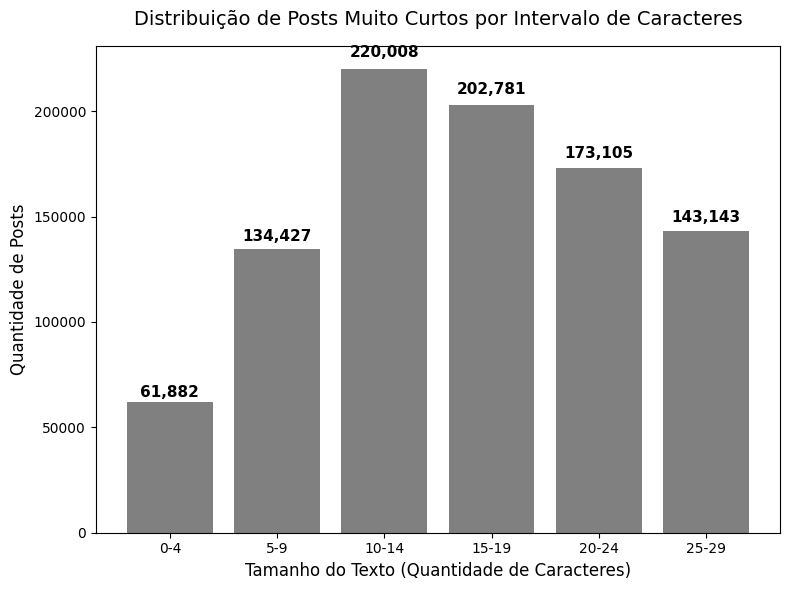

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

tamanhos = df_2['text_clean'].str.len()

bins = [0, 5, 10, 15, 20, 25, 30]
labels = ['0-4', '5-9', '10-14', '15-19', '20-24', '25-29']

# 3. Agrupa os tamanhos nos intervalos e conta quantos posts caíram em cada um
contagem_intervalos = pd.cut(tamanhos, bins=bins, labels=labels, right=False).value_counts().sort_index()

plt.figure(figsize=(8, 6))
barras = plt.bar(contagem_intervalos.index, contagem_intervalos.values, color='gray')

for barra in barras:
    altura = barra.get_height()
    if altura > 0:
        plt.text(barra.get_x() + barra.get_width()/2, altura + (altura * 0.02) + 5, 
                 f'{int(altura):,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Títulos e labels
plt.title('Distribuição de Posts Muito Curtos por Intervalo de Caracteres', fontsize=14, pad=15)
plt.xlabel('Tamanho do Texto (Quantidade de Caracteres)', fontsize=12)
plt.ylabel('Quantidade de Posts', fontsize=12)


plt.tight_layout()
plt.show()

In [15]:
textos_5.head(100)

,id,text,text_clean
152,1k7o4kp,I give up…. 🤦🏽🤷🏽,give
163,1j4ewqx,💯 agree,agree
265,1jfpexs,How is this not the same photo?,photo
304,19e8tn0,"24M, Do I look 30+?",look
311,1ebse50,The state of this sub,state
...,...,...,...
3332,11e4d9,My hero.,hero
3352,15u1j4,One trip,trip
3361,1jpg5z9,Dont be John,john
3365,eo4z2o,I'm just gonna leave this here...,leave


In [17]:
textos_10 = textos_10[textos_10['text_clean'].str.len() > 5]
textos_10.head(30)

,id,text,text_clean
189,1jmwobo,"No one likes you, Elon",like elon
333,1dxr1e8,(27m) Which look is better?,look well
344,v6wi9o,"my lil glo-up, take care of yourself y’all",take care
364,143ry4b,M23 - keep the beard?,keep beard
372,11xw88o,Yes or no to the stache?,stache
377,1ecdall,Keep or Shave?,keep shave
398,1g8r3vl,Does a buzz cut work for me?,buzz work
399,1asev6w,Am i handsome,handsome
415,y0eh00,Asked for advice 5 days ago; before and after.,advice
421,10djlms,before and after seeing a barber,barber


In [16]:
textos_15 = textos_15[textos_15['text_clean'].str.len() > 10]
textos_15.head(10)

,id,text,text_clean
29,1j4dsr9,Even his barber hates him too,even barber hate
82,1jezhvi,Do you think Joe Biden would do this?,think biden would
96,1k70gml,Well done America 🫡🫤,well america
139,1kavfs7,Somebody tell me this isn't real?,somebody tell real
183,1k736sv,Should Katy Perry Be Cancelled?,katy perry cancel
184,1jabzn6,He is very good at diverting the blame,good divert blame
210,1kb05nn,Golf is a cultural thing now...,golf cultural thing
219,1k9dy1r,Here's some words of wisdom for the day!,word wisdom
222,1ilp9gx,she's gonna have more screentime than her husband,screentime husband
229,1kcju1j,Celebrities who died too young,celebrity young


In [16]:
df_2 = df_2[df_2['text_clean'].str.split().str.len() > 1]
ids_validos = df_2['id'].tolist()

In [17]:
print(f"Quantidade de posts após a filtragem {len(ids_validos)}")

Quantidade de posts após a filtragem 1736102


In [18]:
df_2[['id']].to_csv("../data/processed/ids_validos.csv", index=False)

In [19]:
df_2[['id']].to_parquet("../data/processed/ids_validos.parquet", index=False)